In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from summarytools import dfSummary
from skimpy import skim

# EDA
## Exploring the dataset. 

In [2]:
sales = pd.read_csv("dataset/sales_train_evaluation.csv")
calender = pd.read_csv("dataset/calendar.csv")
sprice = pd.read_csv("dataset/sell_prices.csv")

### Focusing on only the Hobbies items

In [3]:
sales = sales[sales.cat_id == "HOBBIES"]

In [4]:
calender.shape, sprice.shape

((1969, 14), (6841121, 4))

In [5]:
sales['item_id'].value_counts()

item_id
HOBBIES_1_001    10
HOBBIES_1_002    10
HOBBIES_1_003    10
HOBBIES_1_004    10
HOBBIES_1_005    10
                 ..
HOBBIES_2_145    10
HOBBIES_2_146    10
HOBBIES_2_147    10
HOBBIES_2_148    10
HOBBIES_2_149    10
Name: count, Length: 565, dtype: int64

In [6]:
sales[sales['item_id'] == "HOBBIES_1_001"]

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
3049,HOBBIES_1_001_CA_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_2,CA,0,0,0,0,...,2,0,2,0,2,2,0,2,0,1
6098,HOBBIES_1_001_CA_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,0,0,0,0,...,2,6,0,1,0,2,1,0,1,0
9147,HOBBIES_1_001_CA_4_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_4,CA,0,0,0,0,...,1,0,3,1,1,1,0,1,2,2
12196,HOBBIES_1_001_TX_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_1,TX,0,0,0,0,...,0,0,0,2,1,0,2,1,0,1
15245,HOBBIES_1_001_TX_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_2,TX,0,0,0,0,...,0,0,0,0,0,2,0,0,0,1
18294,HOBBIES_1_001_TX_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_3,TX,0,0,0,0,...,1,0,3,0,0,3,1,1,2,1
21343,HOBBIES_1_001_WI_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_1,WI,0,0,0,0,...,0,1,0,2,0,0,0,0,1,2
24392,HOBBIES_1_001_WI_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_2,WI,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
27441,HOBBIES_1_001_WI_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
calender['event_type_1'].value_counts()

event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
Name: count, dtype: int64

In [8]:
calender[calender['event_name_2'].notnull()]

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
85,2011-04-24,11113,Sunday,2,4,2011,d_86,OrthodoxEaster,Religious,Easter,Cultural,0,0,0
827,2013-05-05,11315,Sunday,2,5,2013,d_828,OrthodoxEaster,Religious,Cinco De Mayo,Cultural,1,1,1
1177,2014-04-20,11412,Sunday,2,4,2014,d_1178,Easter,Cultural,OrthodoxEaster,Religious,0,0,0
1233,2014-06-15,11420,Sunday,2,6,2014,d_1234,NBAFinalsEnd,Sporting,Father's day,Cultural,0,1,1
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0


In [9]:
calender['event_type_2'].value_counts()

event_type_2
Cultural     4
Religious    1
Name: count, dtype: int64

In [10]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [11]:
sales['item_id'].value_counts()

item_id
HOBBIES_1_001    10
HOBBIES_1_002    10
HOBBIES_1_003    10
HOBBIES_1_004    10
HOBBIES_1_005    10
                 ..
HOBBIES_2_145    10
HOBBIES_2_146    10
HOBBIES_2_147    10
HOBBIES_2_148    10
HOBBIES_2_149    10
Name: count, Length: 565, dtype: int64

In [12]:
ids = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

In [13]:
long = sales.melt(id_vars = ids, var_name = "d", value_name = "units")

In [14]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [15]:
sales.shape

(5650, 1947)

In [16]:
long['d'].value_counts()

d
d_1       5650
d_2       5650
d_3       5650
d_4       5650
d_5       5650
          ... 
d_1937    5650
d_1938    5650
d_1939    5650
d_1940    5650
d_1941    5650
Name: count, Length: 1941, dtype: int64

In [17]:
long.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'units'],
      dtype='str')

In [18]:
long[long['d'] == "d_1"]

,id,item_id,dept_id,cat_id,store_id,state_id,d,units
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...,...
5645,HOBBIES_2_145_WI_3_evaluation,HOBBIES_2_145,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0
5646,HOBBIES_2_146_WI_3_evaluation,HOBBIES_2_146,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0
5647,HOBBIES_2_147_WI_3_evaluation,HOBBIES_2_147,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0
5648,HOBBIES_2_148_WI_3_evaluation,HOBBIES_2_148,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0


In [19]:
sales.dtypes

id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
            ...  
d_1937      int64
d_1938      int64
d_1939      int64
d_1940      int64
d_1941      int64
Length: 1947, dtype: object

In [20]:
long.dtypes

id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
state_id      str
d             str
units       int64
dtype: object

In [21]:
long["units"] = long["units"].astype("int16")

In [22]:
long["d"]

0              d_1
1              d_1
2              d_1
3              d_1
4              d_1
             ...  
10966645    d_1941
10966646    d_1941
10966647    d_1941
10966648    d_1941
10966649    d_1941
Name: d, Length: 10966650, dtype: str

In [23]:
for c in ids[1:]:
    long[c] = long[c].astype("category")
long["d"] = long["d"].str[2:].astype("int16")
calender['d'] = calender['d'].str[2:].astype('int16')

In [24]:
long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0


In [25]:
first_sale = long[long.units > 0].groupby("id", observed=True)["d"].min()

In [26]:
print(f"Long shape before: {long.shape}")
print(f"Long shape after: {first_sale.shape}")

Long shape before: (10966650, 8)
Long shape after: (5650,)


In [27]:
long[long.units > 0].groupby("id", observed=True)["d"].min()

id
HOBBIES_1_001_CA_1_evaluation    902
HOBBIES_1_001_CA_2_evaluation    911
HOBBIES_1_001_CA_3_evaluation    910
HOBBIES_1_001_CA_4_evaluation    901
HOBBIES_1_001_TX_1_evaluation    900
                                ... 
HOBBIES_2_149_TX_2_evaluation    846
HOBBIES_2_149_TX_3_evaluation    844
HOBBIES_2_149_WI_1_evaluation    834
HOBBIES_2_149_WI_2_evaluation    935
HOBBIES_2_149_WI_3_evaluation    883
Name: d, Length: 5650, dtype: int16

In [28]:
n_pairs = sprice.groupby(["store_id","item_id"]).ngroups
n_weeks = sprice.wm_yr_wk.nunique()
print("if rectangular:", n_pairs * n_weeks, "   actual rows:", len(sprice))

if rectangular: 8598180    actual rows: 6841121


In [29]:
sprice

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [30]:
hsprice = sprice[sprice["item_id"].str.contains("HOBBIES")]

In [31]:
count = hsprice.groupby(["store_id", "item_id"])["wm_yr_wk"].nunique() 

In [32]:
hsprice[["store_id","item_id"]].value_counts()

store_id  item_id      
CA_1      HOBBIES_1_008    282
          HOBBIES_1_009    282
          HOBBIES_1_010    282
          HOBBIES_1_012    282
          HOBBIES_1_015    282
                          ... 
TX_2      HOBBIES_2_132     48
WI_3      HOBBIES_2_132     48
CA_4      HOBBIES_2_132     47
WI_3      HOBBIES_1_170     47
CA_4      HOBBIES_1_170     34
Name: count, Length: 5650, dtype: int64

In [33]:
hsprice[hsprice["item_id"] == "HOBBIES_1_034"]

,store_id,item_id,wm_yr_wk,sell_price
7869,CA_1,HOBBIES_1_034,11102,4.66
7870,CA_1,HOBBIES_1_034,11103,4.66
7871,CA_1,HOBBIES_1_034,11104,4.66
7872,CA_1,HOBBIES_1_034,11105,4.66
7873,CA_1,HOBBIES_1_034,11106,4.66
...,...,...,...,...
6153285,WI_3,HOBBIES_1_034,11617,4.86
6153286,WI_3,HOBBIES_1_034,11618,4.86
6153287,WI_3,HOBBIES_1_034,11619,4.86
6153288,WI_3,HOBBIES_1_034,11620,4.86


In [34]:
hsprice

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6274446,WI_3,HOBBIES_2_149,11617,0.97
6274447,WI_3,HOBBIES_2_149,11618,0.97
6274448,WI_3,HOBBIES_2_149,11619,0.97
6274449,WI_3,HOBBIES_2_149,11620,0.97


In [35]:
n_pairs = hsprice.groupby(["store_id","item_id"]).ngroups
n_weeks = hsprice.wm_yr_wk.nunique()
print("if rectangular:", n_pairs * n_weeks, "  actual:", len(hsprice))

if rectangular: 1593300   actual: 1283905


In [36]:
n_pairs

5650

In [37]:
hsprice.shape

(1283905, 4)

In [38]:
counts = hsprice.groupby(["store_id","item_id"])["wm_yr_wk"].nunique()

print(counts.value_counts().sort_index())   # how many pairs have how many weeks

wm_yr_wk
34        1
47        2
48        3
50        3
51        1
       ... 
278      24
279      57
280     137
281     251
282    1853
Name: count, Length: 222, dtype: int64


In [39]:
print(counts.sort_values().head(20))        # the SHORTEST-lived products

store_id  item_id      
CA_4      HOBBIES_1_170    34
          HOBBIES_2_132    47
WI_3      HOBBIES_1_170    47
          HOBBIES_2_132    48
TX_2      HOBBIES_2_132    48
CA_4      HOBBIES_1_063    48
WI_1      HOBBIES_2_132    50
CA_1      HOBBIES_2_132    50
CA_2      HOBBIES_2_132    50
CA_4      HOBBIES_1_234    51
TX_1      HOBBIES_2_026    59
WI_3      HOBBIES_2_026    60
TX_2      HOBBIES_2_026    61
TX_3      HOBBIES_2_026    61
CA_2      HOBBIES_2_026    61
WI_1      HOBBIES_2_041    62
          HOBBIES_2_026    62
CA_4      HOBBIES_2_041    63
          HOBBIES_2_026    65
          HOBBIES_1_274    65
Name: wm_yr_wk, dtype: int64


In [40]:
all_weeks = set(hsprice.wm_yr_wk.unique())
one = hsprice[(hsprice.store_id=="CA_1") & (hsprice.item_id=="HOBBIES_1_170")]
one

,store_id,item_id,wm_yr_wk,sell_price
38256,CA_1,HOBBIES_1_170,11326,17.97
38257,CA_1,HOBBIES_1_170,11327,17.97
38258,CA_1,HOBBIES_1_170,11328,17.97
38259,CA_1,HOBBIES_1_170,11329,17.97
38260,CA_1,HOBBIES_1_170,11330,17.97
...,...,...,...,...
38404,CA_1,HOBBIES_1_170,11617,17.97
38405,CA_1,HOBBIES_1_170,11618,17.97
38406,CA_1,HOBBIES_1_170,11619,17.97
38407,CA_1,HOBBIES_1_170,11620,17.97


In [41]:
long.dtypes

id               str
item_id     category
dept_id     category
cat_id      category
store_id    category
state_id    category
d              int16
units          int16
dtype: object

In [42]:
calender.dtypes

date              str
wm_yr_wk        int64
weekday           str
wday            int64
month           int64
year            int64
d               int16
event_name_1      str
event_type_1      str
event_name_2      str
event_type_2      str
snap_CA         int64
snap_TX         int64
snap_WI         int64
dtype: object

In [43]:
s1 = long.merge(calender[["d", "wm_yr_wk"]], on="d", how="left")

In [44]:
s2 = s1.merge(hsprice, on=["store_id", "item_id", "wm_yr_wk"], how="left")

In [45]:
s2.isna().sum()

id                  0
item_id             0
dept_id             0
cat_id              0
store_id            0
state_id            0
d                   0
units               0
wm_yr_wk            0
sell_price    2165765
dtype: int64

In [46]:
s2.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN


<Axes: xlabel='dept_id'>

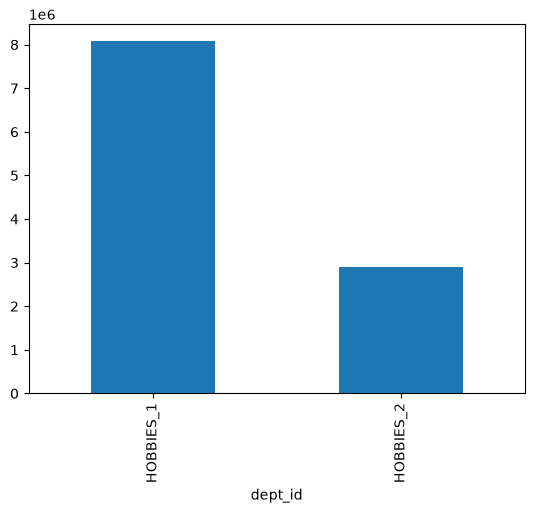

In [47]:
s2['dept_id'].value_counts().plot(kind = "bar")

In [48]:
print(f"Total number of rows", len(s2['sell_price']))
print(f"Missing values for sell price", s2['sell_price'].isna().sum())
print(f"Total items listed: {len(s2['sell_price'])} - {s2['sell_price'].isna().sum()} = {len(s2['sell_price']) - s2['sell_price'].isna().sum()}")

Total number of rows 10966650
Missing values for sell price 2165765
Total items listed: 10966650 - 2165765 = 8800885


In [49]:
hobbies1 = s2[s2['item_id'] == 'HOBBIES_1_001']
len(hobbies1)

19410

In [50]:
hobbies1['sell_price'].isna().sum()

np.int64(9044)

In [51]:
hobbies1

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
565,HOBBIES_1_001_CA_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_2,CA,1,0,11101,NaN
1130,HOBBIES_1_001_CA_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,1,0,11101,NaN
1695,HOBBIES_1_001_CA_4_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_4,CA,1,0,11101,NaN
2260,HOBBIES_1_001_TX_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_1,TX,1,0,11101,NaN
...,...,...,...,...,...,...,...,...,...,...
10963825,HOBBIES_1_001_TX_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_2,TX,1941,1,11617,8.26
10964390,HOBBIES_1_001_TX_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_3,TX,1941,1,11617,8.26
10964955,HOBBIES_1_001_WI_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_1,WI,1941,2,11617,8.38
10965520,HOBBIES_1_001_WI_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_2,WI,1941,0,11617,8.38


In [52]:
# Safely assume that NaN in sell_price means the items was not on the shelf 
s2[(s2['sell_price'].isna()) & (s2['units'] > 0)]

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price


In [53]:
s2['Revenue Generated'] = s2['units'] * s2['sell_price']
s2['Revenue Generated'] = s2['Revenue Generated'].round(2)


In [54]:
s3 = s2.merge(calender, on = ['wm_yr_wk', 'd'], how = 'left')

In [55]:
s3.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [56]:
s3['date'] = pd.to_datetime(s3['date'], format='%Y-%m-%d')

# Step 4: Set Date as index
s3.set_index('date', inplace=True)

In [57]:
s3[['weekday', 'wday']]

,weekday,wday
date,,
2011-01-29,Saturday,1
2011-01-29,Saturday,1
2011-01-29,Saturday,1
2011-01-29,Saturday,1
2011-01-29,Saturday,1
...,...,...
2016-05-22,Sunday,2
2016-05-22,Sunday,2
2016-05-22,Sunday,2


In [58]:
s3.drop(columns = ['weekday'], inplace = True)

In [59]:
s3.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
date,,,,,,,,,,,,,,,,,,,,,
2011-01-29,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [60]:
s3['store_id'].unique()

<ArrowStringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

### Items are evenly distributed throughout the all the stores

<Axes: >

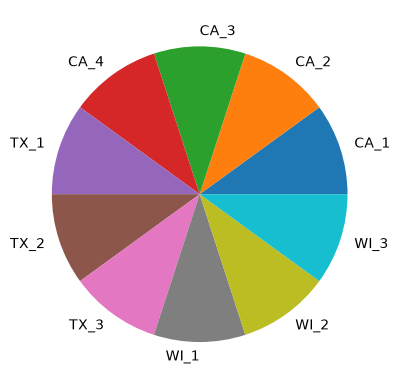

In [61]:
s3.groupby('store_id')['item_id'].count().plot(kind = "pie")

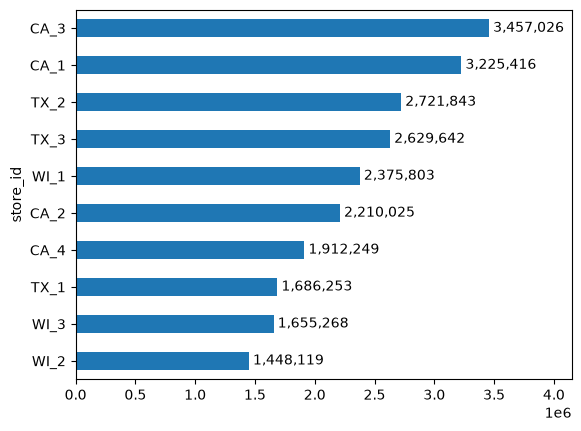

In [62]:
# revenue generated by store over the years

ax = (s3.groupby('store_id')['Revenue Generated'].sum().sort_values().plot(kind = "barh"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
ax.margins(x=0.2)          # stops the labels clipping off the right edge

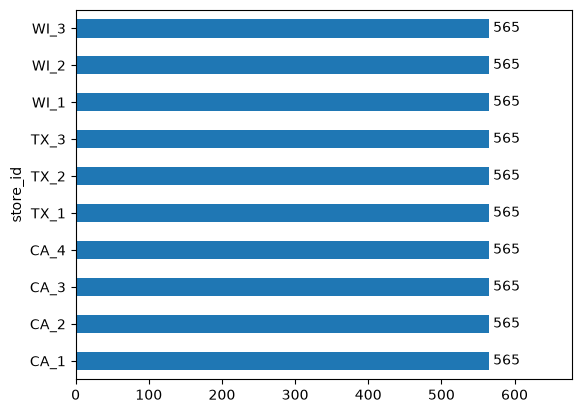

In [63]:
ax = (s3[s3.sell_price.notna()].groupby('store_id', observed=True)['item_id'].nunique().sort_values().plot(kind="barh"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
ax.margins(x=0.2)

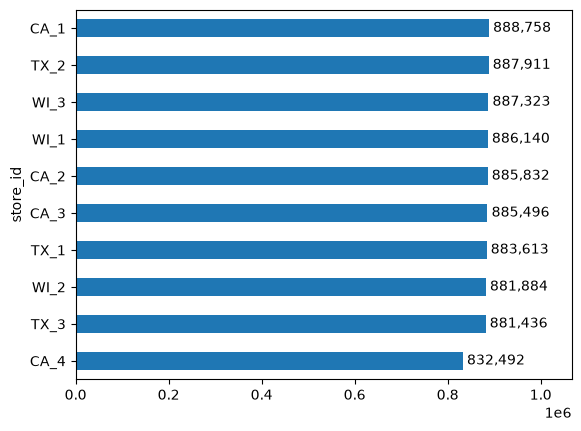

In [64]:
ax = (s3.groupby('store_id', observed=True)['sell_price']
        .count().sort_values().plot(kind="barh"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
ax.margins(x=0.2)          # stops the labels clipping off the right edge

In [65]:
true_products = s3.groupby('store_id', observed=True)['sell_price'].size()
true_products

store_id
CA_1    1096665
CA_2    1096665
CA_3    1096665
CA_4    1096665
TX_1    1096665
TX_2    1096665
TX_3    1096665
WI_1    1096665
WI_2    1096665
WI_3    1096665
Name: sell_price, dtype: int64

In [66]:
current_products = s3.groupby('store_id', observed=True)['sell_price'].count()
current_products

store_id
CA_1    888758
CA_2    885832
CA_3    885496
CA_4    832492
TX_1    883613
TX_2    887911
TX_3    881436
WI_1    886140
WI_2    881884
WI_3    887323
Name: sell_price, dtype: int64

In [67]:
assort_breadth = (current_products/true_products)* 100

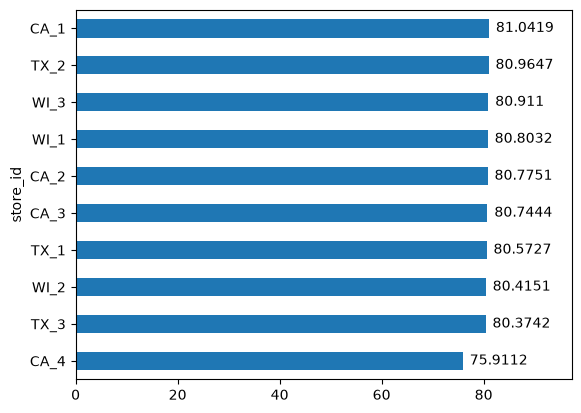

In [68]:
ax_1 = (assort_breadth.sort_values().plot(kind = "barh"))
ax_1.bar_label(ax_1.containers[0], padding=5)
ax_1.margins(x = 0.2)

In [89]:
s3.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
date,,,,,,,,,,,,,,,,,,,,,
2011-01-29,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [98]:
s3.groupby("store_id")['Revenue Generated'].sum().sort_values()

store_id
WI_2    1448119.33
WI_3    1655267.73
TX_1    1686253.39
CA_4    1912249.46
CA_2    2210024.57
WI_1    2375803.38
TX_3    2629641.63
TX_2    2721842.77
CA_1    3225415.88
CA_3    3457026.17
Name: Revenue Generated, dtype: float64

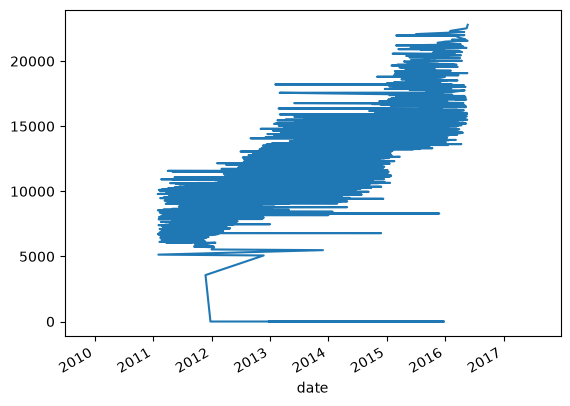

In [101]:
revenue_by_store = (s3.groupby("store_id", 'date')['Revenue Generated'].sum().sort_values().plot(kind = "line"))
revenue_by_store.margins(x = 0.3)

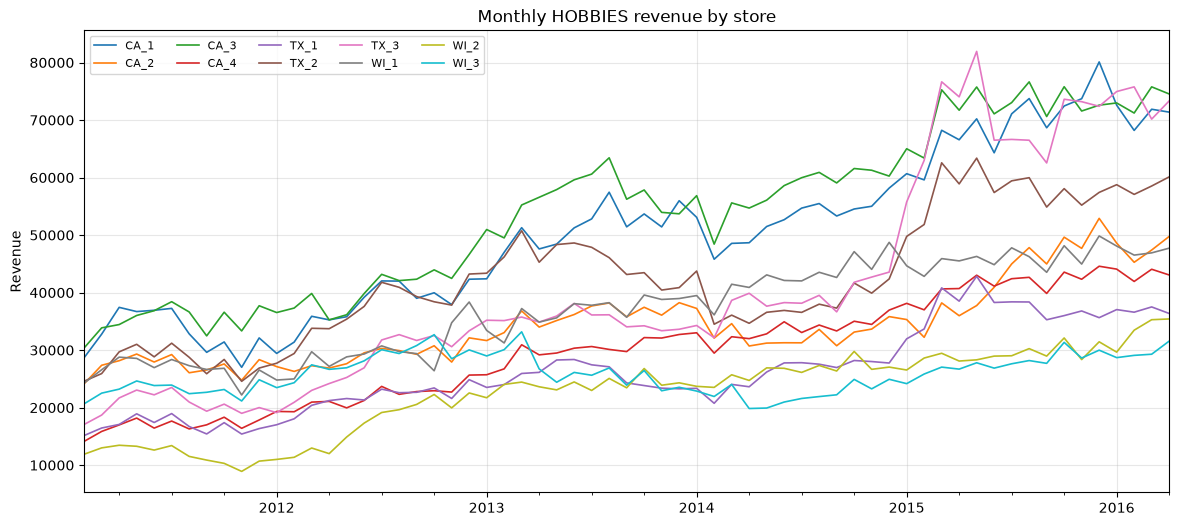

In [102]:
import pandas as pd

ax = (s3.groupby([pd.Grouper(freq="MS"), "store_id"], observed=True)["Revenue Generated"]
        .sum()
        .unstack("store_id")
        .iloc[1:-1]                      # drop the partial first and last month
        .plot(figsize=(14, 6), linewidth=1.2))

ax.set_title("Monthly HOBBIES revenue by store")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.legend(ncol=5, fontsize=8, title=None)
ax.grid(alpha=.3)